# Setting Up Your Python Environment

Enough theory — it's time to build the workbench. Every test, backtest, and analysis in this course runs in Python, and a clean, reproducible setup will save you countless hours of confusing errors later. This lesson walks you through installing Python, isolating your project, getting the core libraries, and pulling and plotting real prices so you know everything works.

By the end of this lesson you will be able to:

- Install Python 3 and confirm it from the command line
- Create and activate an isolated virtual environment with venv or conda
- Install the core data-science libraries and run a Jupyter notebook
- Lay out a clean, reproducible project folder with pinned dependencies
- Pull real price data and plot it in a short hello-world script

## Setp 1 : Install Python3


You need Python 3.10 or newer. Many systems ship with an old version, so check first. Open a terminal a

```
python3 --version
```
If you see something like Python 3.11.x, you're set. If the command is missing or shows Python 2, install a current version:

- Windows: download the installer from python.org and check "Add Python to PATH" during setup.
- macOS: use the python.org installer, or brew install python if you have Homebrew.
- Linux: use your package manager, e.g. sudo apt install python3 python3-venv python3-pip.
  
Confirm pip, Python's package installer, is available too:


```
python3 -m pip --version
```

A quick note on the `python3` versus `python` confusion, which trips up many beginners. On macOS and Linux, `python` historically meant the old `Python 2`, so python3 is the safe choice. On Windows, the installer usually makes `python` mean `Python 3`. If a command "isn't found," try the other name. Once you're inside a virtual environment (next step), python reliably points at that environment's interpreter, and the ambiguity goes away — another quiet reason environments are worth the trouble.

## Step 2: Why virtual environments matter

A **virtual environment is an isolated copy of Python and its packages, scoped to a single project. Without one, every project shares the same global packages — so upgrading a library for one project silently breaks another. With one, each project pins its own versions and nothing leaks.

This is not optional housekeeping; it is the foundation of reproducibility. You have two common tools: `venv` (built into Python) and `conda` (part of the Anaconda/Miniconda distribution). Either is fine. Pick one and be consistent.

To make the problem concrete: imagine you build a strategy in January that relies on a particular version of pandas. In March you start a new project and upgrade pandas for it. Without environments, that upgrade silently changes the behavior of a function your January code depended on — and now last quarter's "reproducible" backtest produces different numbers, with no error message to warn you. Environments make this category of bug impossible by giving each project its own frozen set of libraries. The few seconds it takes to activate an environment buys you immunity from a class of failures that is maddening to debug after the fact.

### OptionA : venv(built in, lightweight)

From inside your project folder:

```
python3 -m venv .venv

```

This creates a `.venv` directory holding the isolated environment. Activate it:

- macOS / Linux: `source .venv/bin/activate`
- Windows (PowerShell): `.venv\Scripts\Activate.ps1`
Your prompt now shows (`.venv`). Everything you install applies only here. To leave, type `deactivate`.


### Option B : 

If you installed Miniconda, create and activate an environment in one go:

```
conda create -n quant python=3.11
conda activate quant

```
Conda can install non-Python dependencies too, which is handy for some scientific packages. Use venv if you want minimal and standard; use conda if you prefer an all-in-one manager. Don't mix the two in a single project.



## Step 3: Install the core libraries
With your environment activated, install the libraries this course relies on:

```
pip install pandas numpy matplotlib scipy yfinance jupyter

```

What each one does:

- pandas — tables and time series; the workhorse for all data handling.
- numpy — fast numerical arrays and math under the hood.
- matplotlib — plotting prices, equity curves, and diagnostics.
- scipy — statistics and optimization for validation work.
- yfinance — a free, convenient way to download historical market data.
- jupyter — interactive notebooks for exploratory research.


>Always confirm your environment is active before installing. Packages installed without an active environment land in your global Python and defeat the entire purpose.

A quick way to verify everything imports cleanly before you rely on it:

In [1]:
import sys
import pandas, numpy, matplotlib, scipy, yfinance

print("Python:", sys.version.split()[0])
for mod in (pandas, numpy, matplotlib, scipy, yfinance):
    print(f"{mod.__name__:12s} {mod.__version__}")

Python: 3.13.0
pandas       2.3.3
numpy        2.5.1
matplotlib   3.11.0
scipy        1.18.0
yfinance     1.4.1


If that prints a version for each library with no ImportError, your stack is installed correctly inside the active environment. If you get an import error, the most common cause is installing into one Python and running another — re-check that (.venv) or your conda env name appears in the prompt of the same terminal you're running code from.



## Step 4: Jupyter notebooks
A **Jupyter notebook** is an interactive document where you write and run code in cells and see output — tables, charts — inline. It's ideal for the exploratory phase of research, where you poke at data and iterate quickly. Launch it from your activated environment:


```
jupyter notebook

```

This opens a browser tab. Create a new Python notebook, type code in a cell, and press Shift+Enter to run it. Use notebooks for exploration; once code becomes reusable (a signal, a backtester), move it into proper .py files in your src/ folder. Notebooks are for thinking; modules are for building.

One habit to adopt early: notebooks let you run cells in any order, which is convenient and dangerous. You can define a variable in cell 5, use it in cell 2, delete cell 5, and your notebook still "works" — until you restart it and everything breaks. Before trusting any notebook result, use "Restart & Run All" to execute every cell top to bottom in a fresh kernel. If it runs clean from top to bottom, the result is real; if it only worked because of some out-of-order state you've since forgotten, you'll find out now rather than after building a strategy on a phantom number.



## Step 5: A clean project structure
Reproducibility starts with structure. Create a folder for your work and lay it out like this:


```
quant-lab/
    .venv/             the virtual environment (never edited by hand)
    data/              downloaded and cleaned datasets
    notebooks/         exploratory research, dated
    src/               reusable code: signals, backtester, utils
    results/           saved figures and backtest outputs
    requirements.txt   pinned dependency versions
    research_log.md    your dated research journal

```

Keep raw data immutable, separate quick exploration (notebooks) from reusable logic (src), and store outputs in results so you never confuse code with results. This is the same layout introduced in the workflow lesson — now you're building it for real.

A small but worthwhile addition once you start using Git for version control: a .gitignore file so you don't commit the things that shouldn't be tracked. The environment and large data files in particular should stay local — anyone can recreate the environment from requirements.txt, and raw data is often large or licensed.

```

.venv/
data/
results/
__pycache__/
.ipynb_checkpoints/


```

The principle is that your repository should contain the recipe (code, pinned dependencies, the research log) rather than the ingredients and leftovers (the multi-gigabyte environment, downloaded data, generated figures). Someone who clones your project should be able to rebuild everything by running your cod

## Step 6: Reproducibility — requirements and seeds
Reproducibility means anyone (including future you) can rerun your work and get the same answer. Two habits make this happen.

**Pin your dependencies**. After installing, freeze the exact versions into a file:

```
pip freeze > requirments.txt
```

Anyone can then recreate your exact environment with `pip install -r requirements.txt`. Commit this file alongside your code. Without it, a library update months later can silently change your results.


**Fix random seeds**. Anything involving randomness — shuffling data, simulations, some model fitting — should start from a fixed seed so results don't change run to run:


In [3]:
import numpy as np

np.random.seed(42)

A result you can't reproduce is not a result you can trust. These two habits cost seconds and prevent days of confusion.

Why seeds matter is easy to demonstrate. Without a fixed seed, two runs of the same simulation give different numbers:

In [4]:
import numpy as np

# no seed: different every run
print(np.random.normal(size=3))
print(np.random.normal(size=3))

# fixed seed: identical every run
np.random.seed(42)
a = np.random.normal(size=3)
np.random.seed(42)
b = np.random.normal(size=3)
print(np.allclose(a, b))   # True

[ 0.49671415 -0.1382643   0.64768854]
[ 1.52302986 -0.23415337 -0.23413696]
True


The first two lines print different triples; the seeded pair are identical. When a backtest involves any randomness — bootstrap resampling, Monte Carlo simulation, a shuffled train/test split — an unfixed seed means you can never tell whether a change in results came from your code or from luck. Seed it, and every difference you see is a real consequence of something you changed.



## Step 7: Hello world — pull and plot real prices
Let's confirm the whole stack works by downloading real price data and plotting it. With your environment active, create a file src/hello_prices.py (or run it in a notebook cell):

[*********************100%***********************]  1 of 1 completed

Ticker            AAPL
Date                  
2022-12-23  129.659409
2022-12-27  127.859940
2022-12-28  123.936531
2022-12-29  127.446938
2022-12-30  127.761604

Download 756 daily prices for AAPL.


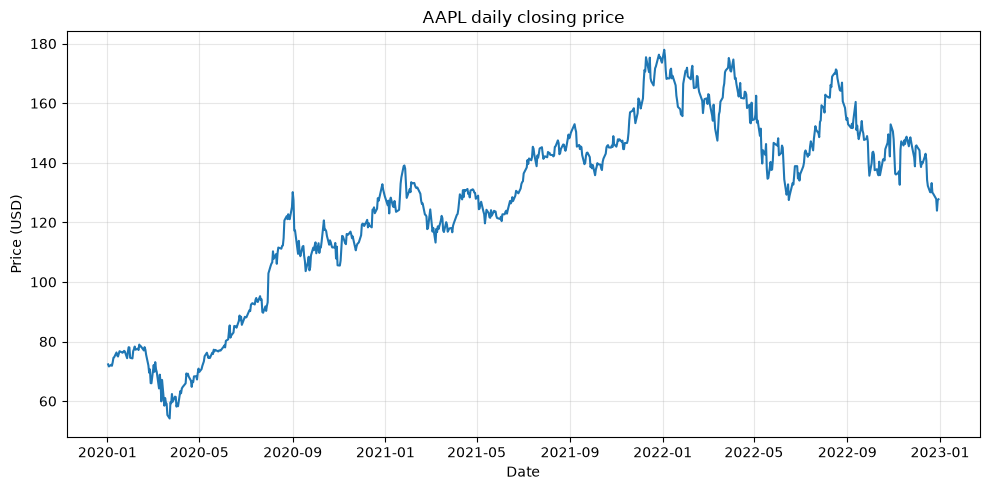

In [6]:
import yfinance as yf
import matplotlib.pyplot as plt


#Download daily data for one ticker
ticker = 'AAPL'
data = yf.download(ticker, start="2020-01-01", end="2023-01-01")

# Use the adjusted close, which accounts for splits and dividends
prices = data["Close"]


print(prices.tail())
print(f"\nDownload {len(prices)} daily prices for {ticker}.")

# Plot the price series
plt.figure(figsize=(10, 5))
plt.plot(prices.index, prices.values)
plt.title(f"{ticker} daily closing price")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("results/aapl_prices.png", dpi=120)
plt.show()

Run it:

In [ ]:
python src/hello_prices.py


If everything is installed correctly, you'll see the last few prices printed, a confirmation count, and a chart of Apple's price saved to `results/aapl_prices.png`. That is your entire toolchain working end to end: data download, pandas handling, and a matplotlib plot.

Let's also add a tiny calculation to prove the data is usable, not just plottable. Daily returns are the foundation of everything later:



In [ ]:
returns = prices.pct_change().dropna()
print(f"Mean daily return: {returns.mean():.5f}")
print(f"Daily volatility:  {returns.std():.5f}")

If those two numbers print without error, your environment is ready for the rest of the course.

## Worked example: a slightly richer hello-world
To stretch the toolchain a little further — and preview ideas from later modules — let's annualize those daily statistics and compute a simple cumulative-return curve. This uses nothing beyond what you've installed, and the numbers it prints are ones you'll learn to interpret deeply later.



In [ ]:
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

data = yf.download("AAPL", start="2020-01-01", end="2023-01-01")
prices = data["Close"]
returns = prices.pct_change().dropna()

# Annualize: ~252 trading days per year
ann_return = returns.mean() * 252
ann_vol = returns.std() * np.sqrt(252)
sharpe = ann_return / ann_vol     # crude, ignores the risk-free rate

print(f"Annualized return:     {ann_return:6.2%}")
print(f"Annualized volatility: {ann_vol:6.2%}")
print(f"Crude Sharpe ratio:    {sharpe:6.2f}")

# Cumulative growth of $1 invested
equity = (1 + returns).cumprod()
plt.figure(figsize=(10, 5))
plt.plot(equity.index, equity.values)
plt.title("Growth of $1 in AAPL")
plt.ylabel("Equity (multiple of start)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("results/aapl_equity.png", dpi=120)
plt.show()

Notice the two scaling rules, which you'll see constantly: average daily return scales by multiplying by 252 (the rough number of trading days in a year), while volatility scales by the square root of 252, because risk grows with the square root of time, not linearly. The "crude Sharpe" combines them into a single return-per-unit-of-risk number — the metric we'll define properly in the performance module. For now, the point is simply that your environment can already compute the things real analysis is built from.



## Common mistakes
- Installing into the global Python. Forgetting to activate your environment scatters packages globally and breaks other projects. Check for (.venv) or your conda env name in the prompt first.
- Skipping requirements.txt. Without pinned versions, a future library update can silently change your results, and you'll have no way to reproduce the original.
- Mixing venv and conda in one project. Pick one tool per project; mixing them produces confusing, hard-to-diagnose conflicts.
- Editing raw data by hand. Hand-editing files in data/ destroys reproducibility. Always transform data in code so the steps are recorded.
- Living entirely in notebooks. Notebooks are great for exploration but encourage messy, out-of-order execution. Move reusable code into src/ modules.
- Using raw close instead of adjusted close. Ignoring splits and dividends corrupts long-run return calculations.